In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CHARGER DONNÉES
# =========================================================

features = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx")
ops = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls")

features["compte"] = features["compte"].astype(str)
ops["compte"] = ops["compte"].astype(str)
ops["date_operation"] = pd.to_datetime(ops["date_operation"])

# Définition nuit / jour
ops["heure"] = ops["date_operation"].dt.hour
ops["is_night"] = ((ops["heure"] >= 22) | (ops["heure"] <= 6)).astype(int)



================ CAS 1 — MONTANTS ASCENDANTS =================
Nombre de comptes suspects : 28
['14010123110901222222', '14010123111000444444', '14010123110719660761', '14010123117444444444', '14010123120999999999', '14010123120666666666', '14010123120222222222', '14010123119999999999', '14010123119666666666', '14010123119222222222', '14010123118999999999', '14010123118666666666', '14010123118333333333', '14010123118000000000', '14010123117777777777', '14010123117111111111', '14010123110730028509', '14010123116888888888', '14010123116555555555', '14010123111000777777', '14010123111000666666', '14010123111000555555', '14010123111000333333', '14010123111000222222', '14010123111000111111', '14010123110901333333', '14010123110739788843', '14010123121222222222']

Statistiques :
count    28.000000
mean      5.071429
std       0.262265
min       5.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       6.000000
Name: montants_croissants_consecutifs, dtype: float64


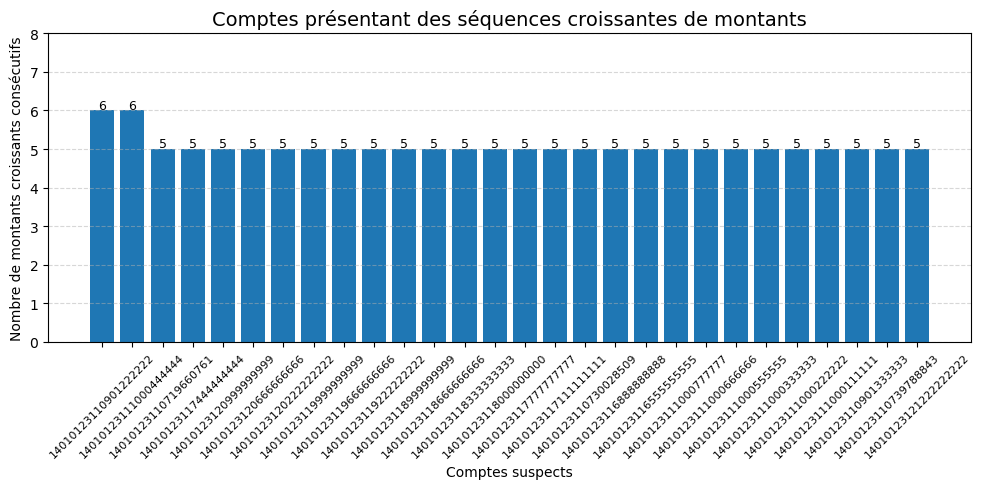

In [23]:
# CAS 1 — MONTANTS ASCENDANTS RAPIDES
# Visualisation améliorée
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# Comptes suspects
cas1 = features[
    features["montants_croissants_consecutifs"] >= 5
].copy()

# Tri décroissant pour meilleure lisibilité
cas1 = cas1.sort_values(
    by="montants_croissants_consecutifs",
    ascending=False
)

print("\n================ CAS 1 — MONTANTS ASCENDANTS =================")
print("Nombre de comptes suspects :", len(cas1))
print(cas1["compte"].tolist())

# =========================================================
# STATISTIQUES RAPIDES
# =========================================================

print("\nStatistiques :")
print(
    cas1["montants_croissants_consecutifs"]
    .describe()
)

# =========================================================
# VISUALISATION PRINCIPALE
# =========================================================

plt.figure(figsize=(10, 5))

bars = plt.bar(
    range(len(cas1)),
    cas1["montants_croissants_consecutifs"]
)

# Valeurs au-dessus des barres
for i, v in enumerate(cas1["montants_croissants_consecutifs"]):
    plt.text(
        i,
        v + 0.05,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title(
    "Comptes présentant des séquences croissantes de montants",
    fontsize=14
)

plt.xlabel("Comptes suspects")
plt.ylabel("Nombre de montants croissants consécutifs")

# Affichage d’un compte sur deux pour éviter surcharge
plt.xticks(
    ticks=range(len(cas1)),
    labels=cas1["compte"],
    rotation=45,
    fontsize=8
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Meilleure échelle Y
plt.ylim(
    0,
    cas1["montants_croissants_consecutifs"].max() + 2
)

plt.tight_layout()
plt.show()


================ CAS 2 — LIEUX IMPOSSIBLES =================
Nombre de comptes suspects : 101


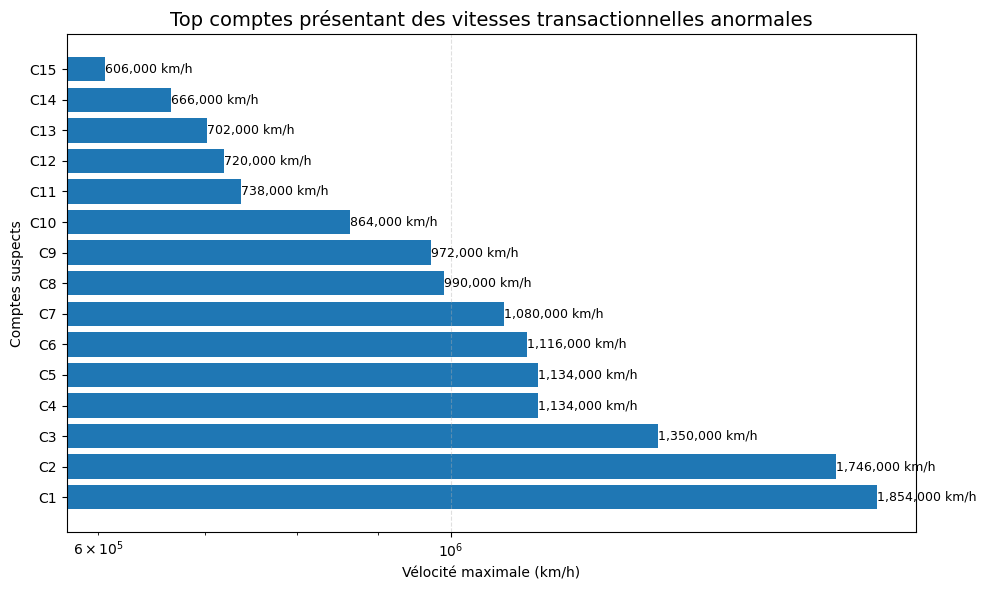

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


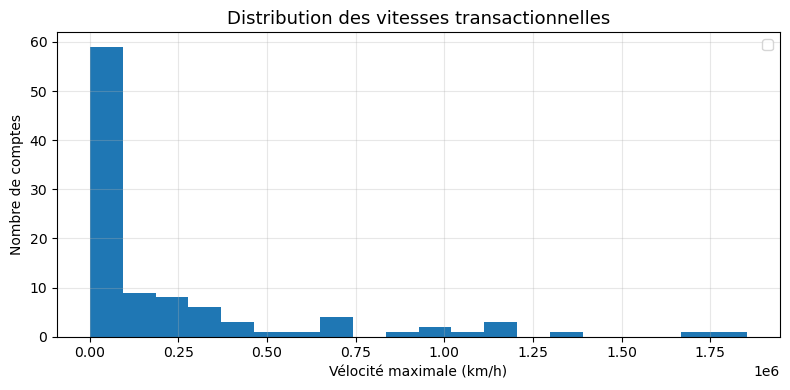

In [24]:
# =========================================================
# CAS 2 — LIEUX IMPOSSIBLES (VÉLOCITÉ)
# Visualisation professionnelle
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# Comptes suspects
cas2 = features[
    features["velocite_maximale_km_h"] > 500
].copy()

# Trier par vitesse décroissante
cas2 = cas2.sort_values(
    by="velocite_maximale_km_h",
    ascending=False
)

print("\n================ CAS 2 — LIEUX IMPOSSIBLES =================")
print("Nombre de comptes suspects :", len(cas2))

# =========================================================
# TOP 15 seulement pour lisibilité
# =========================================================

top_n = 15

top_velocite = cas2.head(top_n).copy()

# Labels simplifiés
top_velocite["label"] = [
    f"C{i+1}" for i in range(len(top_velocite))
]

# =========================================================
# BARPLOT HORIZONTAL
# =========================================================

plt.figure(figsize=(10, 6))

plt.barh(
    top_velocite["label"],
    top_velocite["velocite_maximale_km_h"]
)

# Valeurs sur les barres
for i, v in enumerate(top_velocite["velocite_maximale_km_h"]):
    plt.text(
        v,
        i,
        f"{v:,.0f} km/h",
        va='center',
        fontsize=9
    )

plt.title(
    "Top comptes présentant des vitesses transactionnelles anormales",
    fontsize=14
)

plt.xlabel("Vélocité maximale (km/h)")
plt.ylabel("Comptes suspects")

# Échelle logarithmique
plt.xscale("log")

# Grille
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
# =========================================================
# DISTRIBUTION GLOBALE
# =========================================================

plt.figure(figsize=(8, 4))

plt.hist(
    cas2["velocite_maximale_km_h"],
    bins=20
)

plt.title(
    "Distribution des vitesses transactionnelles",
    fontsize=13
)

plt.xlabel("Vélocité maximale (km/h)")
plt.ylabel("Nombre de comptes")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

                 compte  nb_transactions  total_montant  montant_moyen  \
0  14010123110699999232                1        200.000     200.000000   
1  14010123110700003794                7     152822.507   21831.786714   
2  14010123110700011651               37     301128.810    8138.616486   
3  14010123110700016903                3        784.174     261.391333   
4  14010123110700017388                5        216.625      43.325000   

   montant_median   montant_std  montant_min  montant_max  \
0         200.000      0.000000      200.000       200.00   
1         413.703  36876.433965       10.000     75812.50   
2        4507.067   9309.718094       29.900     31550.66   
3         200.000    268.234818       29.174       555.00   
4          27.000     33.786646       20.000       100.00   

   duree_activite_jours  ratio_max_moyen  ...  temps_moyen_entre_tx_min  \
0                     1         1.000000  ...                  0.000000   
1                   149         3.4725

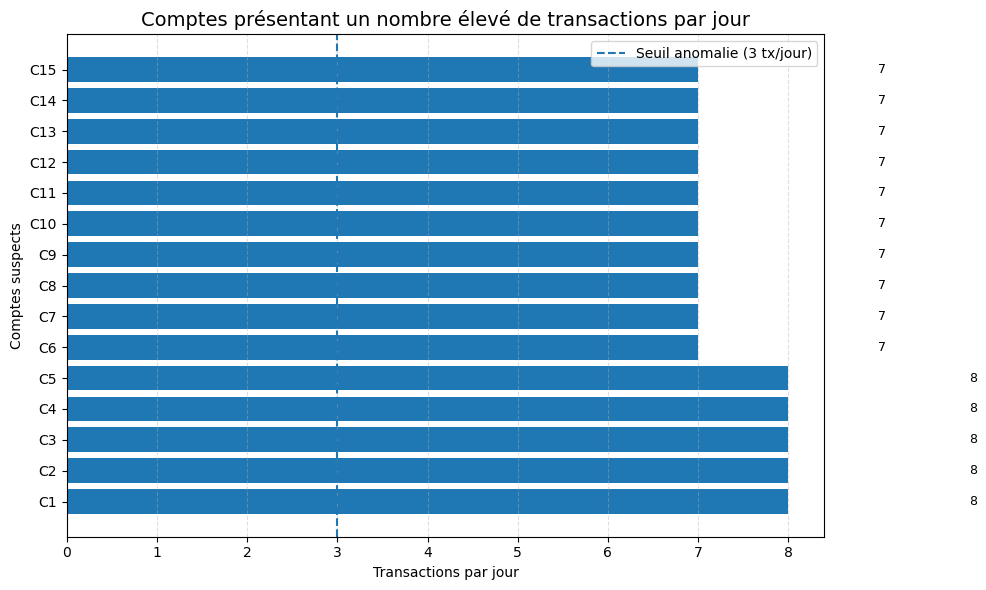

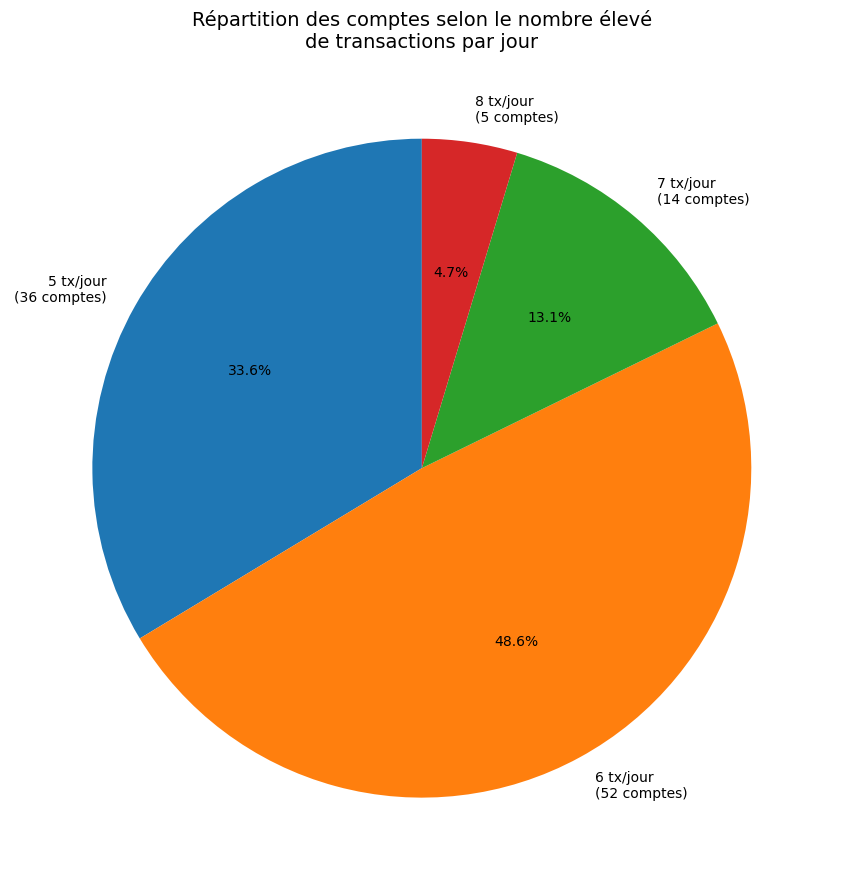

In [40]:
# CAS 3 — NOMBRE ÉLEVÉ DE TRANSACTIONS PAR JOUR
# =========================================================
import pandas as pd

# Chargement du fichier
features_comptes = pd.read_excel(
    r"C:\Users\Pc\Desktop\new\features_comptes.xlsx"
)

# Vérification
print(features_comptes.head())


import matplotlib.pyplot as plt

# Seuil suspicion
SEUIL_TX_JOUR = 3

# Comptes suspects
cas3 = features_comptes[
    features_comptes["tx_par_jour"] > SEUIL_TX_JOUR
].copy()

# Tri décroissant
cas3 = cas3.sort_values(
    by="tx_par_jour",
    ascending=False
)

print("\n================ CAS 3 — TRANSACTIONS ÉLEVÉES =================")
print("Nombre de comptes suspects :", len(cas3))

# =========================================================
# TOP 15 comptes
# =========================================================

top_n = 15

top_tx = cas3.head(top_n).copy()

# Labels simplifiés
top_tx["label"] = [
    f"C{i+1}" for i in range(len(top_tx))
]

# =========================================================
# VISUALISATION
# =========================================================

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_tx["label"],
    top_tx["tx_par_jour"]
)

# Ligne seuil
plt.axvline(
    x=SEUIL_TX_JOUR,
    linestyle="--",
    label=f"Seuil anomalie ({SEUIL_TX_JOUR} tx/jour)"
)

# Affichage valeurs
for i, v in enumerate(top_tx["tx_par_jour"]):
    plt.text(
        v + 2,
        i,
        str(int(v)),
        va='center',
        fontsize=9
    )

plt.title(
    "Comptes présentant un nombre élevé de transactions par jour",
    fontsize=14
)

plt.xlabel("Transactions par jour")
plt.ylabel("Comptes suspects")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# DIAGRAMME EN SECTEUR — TX PAR JOUR SUSPECTES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Chargement fichier
features_comptes = pd.read_excel(
    r"C:\Users\Pc\Desktop\new\features_comptes.xlsx"
)

# =========================================================
# FILTRAGE DES COMPTES SUSPECTS
# =========================================================

SEUIL_TX_JOUR = 4

cas3 = features_comptes[
    features_comptes["tx_par_jour"] > SEUIL_TX_JOUR
].copy()

# =========================================================
# COMPTER LE NOMBRE D'OCCURRENCES
# Exemple :
# 4 tx/jour -> 30 comptes
# 5 tx/jour -> 20 comptes
# =========================================================

distribution = (
    cas3["tx_par_jour"]
    .round()
    .astype(int)
    .value_counts()
    .sort_index()
)

# =========================================================
# LABELS
# =========================================================

labels = [
    f"{tx} tx/jour\n({nb} comptes)"
    for tx, nb in zip(distribution.index, distribution.values)
]

# =========================================================
# VISUALISATION
# =========================================================

plt.figure(figsize=(9, 9))

plt.pie(
    distribution.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    "Répartition des comptes selon le nombre élevé\n"
    "de transactions par jour",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [26]:
# =========================================
# FONCTION VISUALISATION D'UN COMPTE
# =========================================

def plot_compte_behavior(compte_id):

    df = ops[ops["compte"] == compte_id].sort_values("date_operation").copy()

    if len(df) < 6:
        print("Pas assez de transactions")
        return

    # split ancien / récent
    df["rank"] = np.arange(len(df))
    split = len(df) // 2

    ancienne = df.iloc[:split]
    recente = df.iloc[split:]

    print("\n==============================")
    print("Compte:", compte_id)
    print("Ancienne % nuit:", ancienne["is_night"].mean())
    print("Récente % nuit:", recente["is_night"].mean())

    # ---------- PLOT TIMELINE ----------
    plt.figure(figsize=(12,5))

    colors = df["is_night"].map({0:"blue", 1:"red"})

    plt.scatter(
        df["date_operation"],
        df["montant"],
        c=colors,
        s=80
    )

    plt.axvline(df.iloc[split]["date_operation"], linestyle="--")

    plt.title(f"Comportement transactions — Compte {compte_id}")
    plt.xlabel("Date")
    plt.ylabel("Montant")
    plt.show()


Comptes changement jour → nuit : 9
['14010123110729128058', '14010123110800123456', '14010123110800234567', '14010123110800345678', '14010123110800456789', '14010123110800567890', '14010123110800678901', '14010123110800789012', '14010123110800890123']

Compte: 14010123110729128058
Ancienne % nuit: 0.2
Récente % nuit: 0.8333333333333334


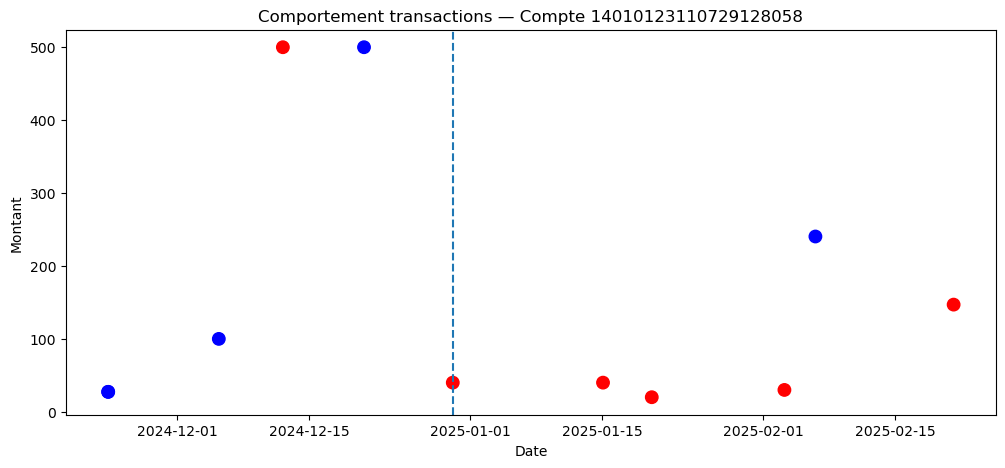


Compte: 14010123110800123456
Ancienne % nuit: 0.0
Récente % nuit: 0.8181818181818182


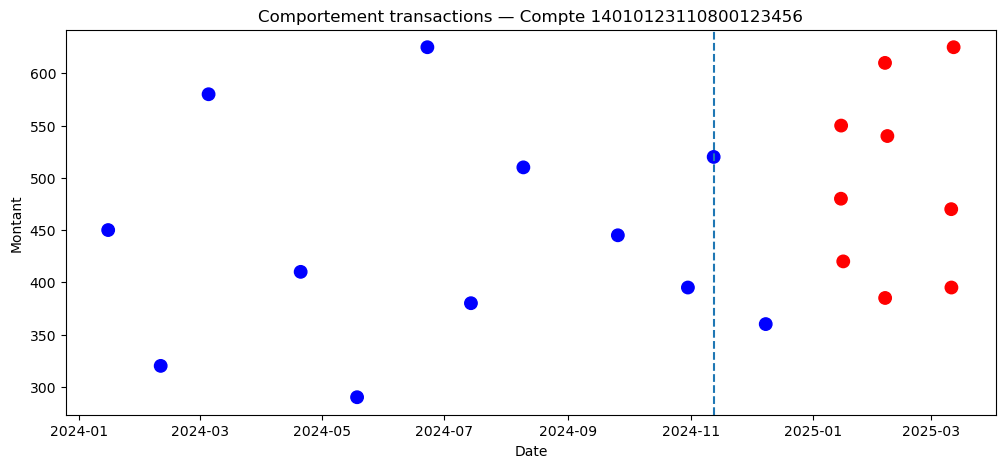


Compte: 14010123110800234567
Ancienne % nuit: 0.0
Récente % nuit: 0.9


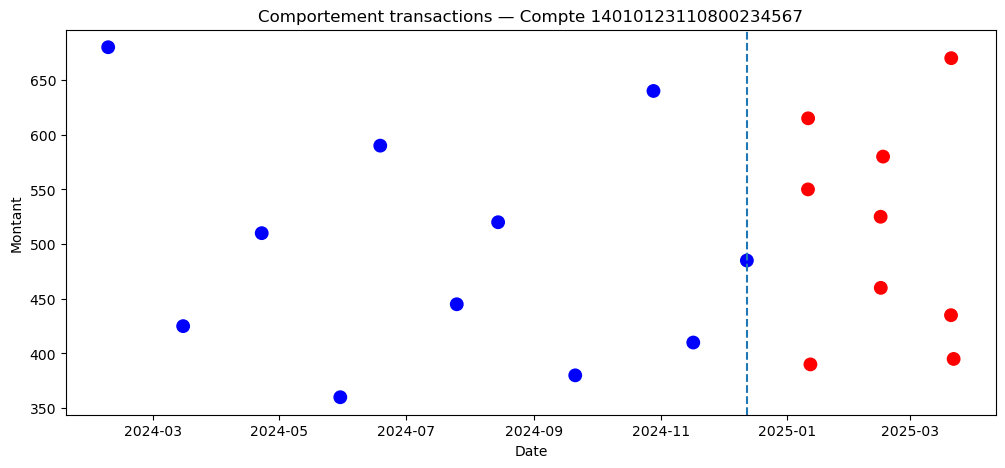


Compte: 14010123110800345678
Ancienne % nuit: 0.0
Récente % nuit: 0.8181818181818182


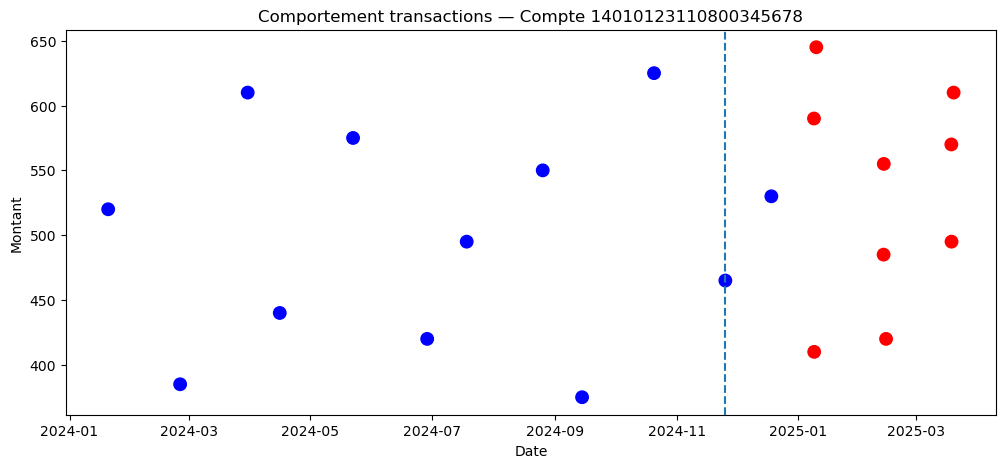


Compte: 14010123110800456789
Ancienne % nuit: 0.0
Récente % nuit: 0.9


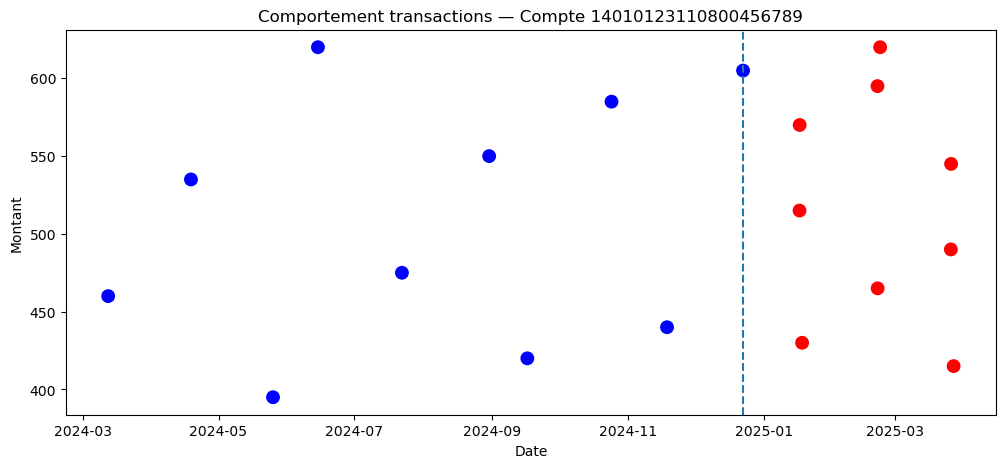

In [27]:
# =========================================
# DÉTECTER COMPTES QUI BASCULENT JOUR→NUIT
# =========================================

suspects_shift = []

for c, g in ops.groupby("compte"):

    if len(g) < 10:
        continue

    g = g.sort_values("date_operation")
    split = len(g)//2

    ancienne = g.iloc[:split]
    recente = g.iloc[split:]

    pct_old = ancienne["is_night"].mean()
    pct_new = recente["is_night"].mean()

    if pct_old < 0.25 and pct_new > 0.8:
        suspects_shift.append(c)

print("\nComptes changement jour → nuit :", len(suspects_shift))
print(suspects_shift[:20])

# =========================================
# VISUALISER LES 5 PREMIERS
# =========================================

for c in suspects_shift[:5]:
    plot_compte_behavior(c)